In [1]:
import pandas as pd

df = pd.read_csv('reviews.csv')
print(df.head())

# Cleaning data
print('\nBefore:')
print(df.isna().sum())
del df['reviewer_name']
print('\nAfter:')
print(df.isna().sum())

# Long text
print('\nLong text:')
df['long_text'] = df['review_text'].apply(lambda x: len(str(x).split()))
print(df['long_text'].max())

                                           review_id  reviewer_name  rating  \
0  Ci9DQUlRQUNvZENodHljRjlvT25NMVYxOUNjMmxRVlhsS0...            NaN     2.0   
1  Ci9DQUlRQUNvZENodHljRjlvT213elJteGZOM2RsUkhKQl...            NaN     4.0   
2  Ci9DQUlRQUNvZENodHljRjlvT21KWGJGOXZRbmt5ZFhObU...            NaN     1.0   
3  Ci9DQUlRQUNvZENodHljRjlvT21OUk4zaEhRMWhWUnpneV...            NaN     1.0   
4  Ci9DQUlRQUNvZENodHljRjlvT2tsc1Ixa3hWMWhJV1drMl...            NaN     1.0   

                                         review_text           scraped_at  
0  Rasa mie nya beda, pucettttt ga seperti biasan...  2026-08-31T16:52:13  
1  Seperti biasa, mie gacoan selalu ramai pengunj...  2026-08-31T16:52:13  
2  Dari awal kesini jujur sistem pemesanan nya ri...  2026-08-31T16:52:13  
3  Mungkin hari sialnya saya, udah sering dateng ...  2026-08-31T16:52:20  
4  padahal antrian lagi rame bgt, waiting list ju...  2026-08-31T16:52:20  

Before:
review_id           0
reviewer_name    1000
rating          

In [2]:
# Text cleaning function
import re

def clean_review_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove special characters (keep only letters, digits, and spaces)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply to our DataFrame using .apply()
df['review_text_cleaned'] = df['review_text'].apply(clean_review_text)

print(df[['review_text', 'review_text_cleaned']])

                                           review_text  \
0    Rasa mie nya beda, pucettttt ga seperti biasan...   
1    Seperti biasa, mie gacoan selalu ramai pengunj...   
2    Dari awal kesini jujur sistem pemesanan nya ri...   
3    Mungkin hari sialnya saya, udah sering dateng ...   
4    padahal antrian lagi rame bgt, waiting list ju...   
..                                                 ...   
995  makanannya enak, pelayanannya baik, dan tempat...   
996  Pelayanan lama malah orang lain yang didahuluk...   
997              tempat nya nyaman pelayanan nya baik🥰   
998                               Mantaplah makanannya   
999          mantap bangett enak dan tempat nya nyaman   

                                   review_text_cleaned  
0    rasa mie nya beda pucettttt ga seperti biasany...  
1    seperti biasa mie gacoan selalu ramai pengunju...  
2    dari awal kesini jujur sistem pemesanan nya ri...  
3    mungkin hari sialnya saya udah sering dateng k...  
4    padahal antri

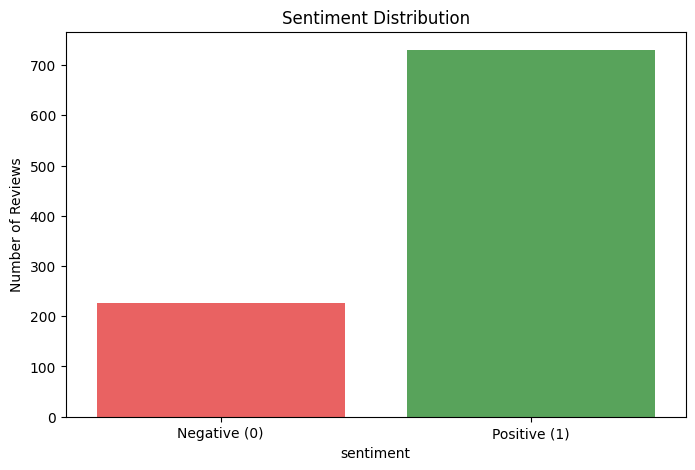


Training Binary XGBoost model...

--- Binary Classification Report ---
              precision    recall  f1-score   support

Negative (0)       0.76      0.83      0.79        46
Positive (1)       0.94      0.92      0.93       146

    accuracy                           0.90       192
   macro avg       0.85      0.87      0.86       192
weighted avg       0.90      0.90      0.90       192



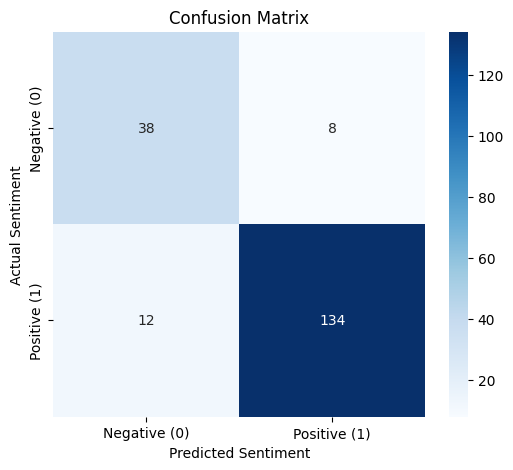

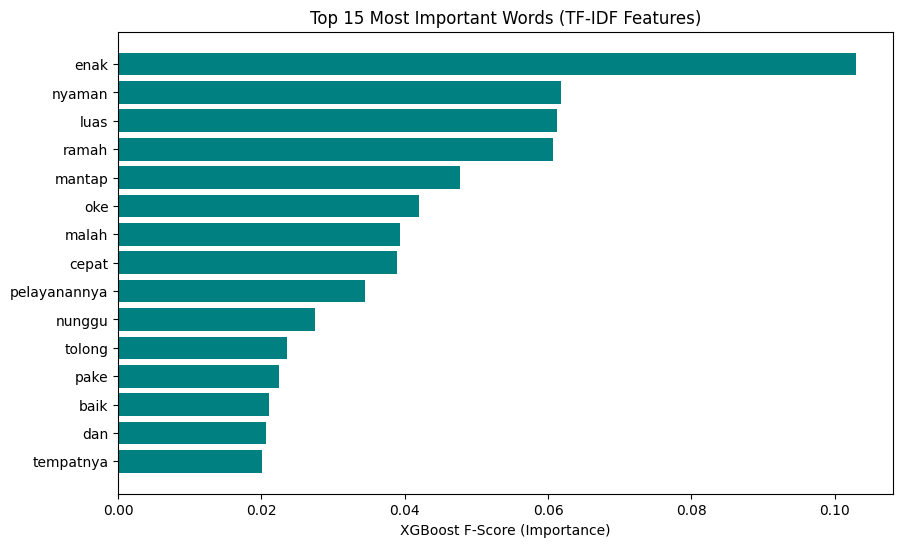


--- Testing Custom Input ---
Review: 'Sistem pesannya ribet banget, padahal banyak meja kosong tapi disuruh nunggu.' -> Predicted Sentiment: Negative (0)
Review: 'Rasa mienya lumayan enak dan harganya murah, cocok buat tanggal tua.' -> Predicted Sentiment: Positive (1)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings

warnings.filterwarnings('ignore')
# Preprocessing
# Decision: Drop 3-star reviews completely to remove the ambiguous middle ground.
# 1-2 Stars = Negative (0), 4-5 Stars = Positive (1)
df_binary = df[df['rating'] != 3.0].copy()

def map_binary_sentiment(rating):
    return 0 if rating <= 2.0 else 1

df_binary['sentiment'] = df_binary['rating'].apply(map_binary_sentiment)

# Visualize
plt.figure(figsize=(8, 5))
sns.countplot(data=df_binary, x='sentiment', palette=['#ff4c4c', '#4caf50'])
plt.title('Sentiment Distribution')
plt.xticks(ticks=[0, 1], labels=['Negative (0)', 'Positive (1)'])
plt.ylabel('Number of Reviews')
plt.show()

# Split data
X = df_binary['review_text']
y = df_binary['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Text vektorization
vectorizer = TfidfVectorizer(
    max_features=5000, 
    min_df=3, 
    max_df=0.8, 
    lowercase=True
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Calculate scale_pos_weight to handle imbalance in binary classification natively
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
imbalance_ratio = negative_count / positive_count

# Update objective to binary:logistic
model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=imbalance_ratio, # Automatically penalizes errors on the minority class
    random_state=42
)

print("\nTraining Binary XGBoost model...")
model.fit(X_train_vec, y_train)

# Evaluation
y_pred = model.predict(X_test_vec)
target_names = ['Negative (0)', 'Positive (1)']

print("\n--- Binary Classification Report ---")
print(classification_report(y_test, y_pred, target_names=target_names))

# Simpan metrik ke dictionary bersama supaya bisa dibandingkan dengan model lain di akhir notebook
from sklearn.metrics import accuracy_score, f1_score
if 'model_results' not in globals():
    model_results = {}
model_results['XGBoost'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred, average='weighted')
}

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

# Visualize feature importance
# Extract the top words that XGBoost relies on to make its predictions
feature_names = vectorizer.get_feature_names_out()
importances = model.feature_importances_

# Get the indices of the top 15 most important features
top_indices = np.argsort(importances)[-15:]
top_features = [feature_names[i] for i in top_indices]
top_importances = importances[top_indices]

plt.figure(figsize=(10, 6))
plt.barh(top_features, top_importances, color='teal')
plt.title('Top 15 Most Important Words (TF-IDF Features)')
plt.xlabel('XGBoost F-Score (Importance)')
plt.show()

# Predict new dataset
print("\n--- Testing Custom Input ---")
new_reviews = [
    "Sistem pesannya ribet banget, padahal banyak meja kosong tapi disuruh nunggu.",
    "Rasa mienya lumayan enak dan harganya murah, cocok buat tanggal tua."
]
new_reviews_vec = vectorizer.transform(new_reviews)
predictions = model.predict(new_reviews_vec)

for review, pred in zip(new_reviews, predictions):
    print(f"Review: '{review}' -> Predicted Sentiment: {target_names[pred]}")

In [4]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

MODEL_NAME = "indobenchmark/indobert-base-p1"  # Indonesian-specific BERT

# Load & preprocess 
df = pd.read_csv("reviews.csv").drop(columns=["reviewer_name"])
df = df[df["rating"] != 3.0].copy()
df["sentiment"] = (df["rating"] > 2.0).astype(int)  # 0 = negative, 1 = positive

X_train, X_test, y_train, y_test = train_test_split(
    df["review_text"].astype(str).tolist(), df["sentiment"].tolist(),
    test_size=0.2, random_state=42, stratify=df["sentiment"]
)

# Tokenization 
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenize = lambda texts: tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
train_enc, test_enc = tokenize(X_train), tokenize(X_test)


class ReviewDataset(Dataset):
    """Wraps tokenized inputs + labels into the format Trainer expects."""
    def __init__(self, encodings, labels):
        self.encodings, self.labels = encodings, labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


train_dataset = ReviewDataset(train_enc, y_train)
test_dataset = ReviewDataset(test_enc, y_test)

# Model 
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# Class imbalance handling (like scale_pos_weight in XGBoost) 
class_weights = torch.tensor([1.0, y_train.count(0) / y_train.count(1)], dtype=torch.float)


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        logits = model(**inputs).logits
        loss = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))(logits, labels)
        return (loss, {"logits": logits}) if return_outputs else loss


# Training 
training_args = TrainingArguments(
    output_dir="./indobert-sentiment",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_steps=10,
)

trainer = WeightedTrainer(model=model, args=training_args, train_dataset=train_dataset, eval_dataset=test_dataset)

print("\nTraining IndoBERT model...")
trainer.train()

# Evaluation 
y_pred = np.argmax(trainer.predict(test_dataset).predictions, axis=1)
target_names = ["Negative (0)", "Positive (1)"]

print("\n Binary Classification Report (IndoBERT) ")
print(classification_report(y_test, y_pred, target_names=target_names))
print(confusion_matrix(y_test, y_pred))

# Simpan metrik ke dictionary bersama supaya bisa dibandingkan dengan model lain di akhir notebook
if 'model_results' not in globals():
    model_results = {}
model_results['IndoBERT'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred, average='weighted')
}

# Inference on new reviews 
new_reviews = [
    "Sistem pesannya ribet banget, padahal banyak meja kosong tapi disuruh nunggu.",
    "Rasa mienya lumayan enak dan harganya murah, cocok buat tanggal tua.",
]

model.eval()
inputs = {k: v.to(model.device) for k, v in tokenizer(new_reviews, padding=True, truncation=True, return_tensors="pt").items()}
with torch.no_grad():
    preds = torch.argmax(model(**inputs).logits, dim=1).tolist()

print("\n Testing Custom Input ")
for review, pred in zip(new_reviews, preds):
    print(f"Review: '{review}' -> Predicted Sentiment: {target_names[pred]}")

# Save model for reuse without retraining 
trainer.save_model("./indobert-sentiment-final")
tokenizer.save_pretrained("./indobert-sentiment-final")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training IndoBERT model...


Epoch,Training Loss,Validation Loss
1,0.230413,0.067935
2,0.111334,0.062190
3,0.004962,0.076005
4,0.026199,0.074292
5,0.000896,0.100706
6,0.000707,0.107317
7,0.000922,0.100398
8,0.000639,0.098677
9,0.000468,0.098725
10,0.000541,0.099001


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


 Binary Classification Report (IndoBERT) 
              precision    recall  f1-score   support

Negative (0)       0.94      0.96      0.95        46
Positive (1)       0.99      0.98      0.98       146

    accuracy                           0.97       192
   macro avg       0.96      0.97      0.96       192
weighted avg       0.97      0.97      0.97       192

[[ 44   2]
 [  3 143]]

 Testing Custom Input 
Review: 'Sistem pesannya ribet banget, padahal banyak meja kosong tapi disuruh nunggu.' -> Predicted Sentiment: Negative (0)
Review: 'Rasa mienya lumayan enak dan harganya murah, cocok buat tanggal tua.' -> Predicted Sentiment: Positive (1)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./indobert-sentiment-final\\tokenizer_config.json',
 './indobert-sentiment-final\\tokenizer.json')

## Comparison with Deep Learning Models: RNN, LSTM, and GRU

After comparing the classical approach (TF-IDF + XGBoost) with a transformer (IndoBERT), three sequential neural network architectures are added here as further baselines: **RNN**, **LSTM**, and **GRU**. All three use the exact same preprocessing, data split, and training loop so the comparison is fair.

In [5]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reuse the same binary-sentiment dataframe from the XGBoost step (df_binary),
# but use the already-cleaned text column (review_text_cleaned) from an earlier cell.
X_train_text, X_test_text, y_train_dl, y_test_dl = train_test_split(
    df_binary['review_text_cleaned'], df_binary['sentiment'],
    test_size=0.2, random_state=42, stratify=df_binary['sentiment']
)

X_train_text = X_train_text.tolist()
X_test_text = X_test_text.tolist()
y_train_dl = y_train_dl.tolist()
y_test_dl = y_test_dl.tolist()

# Build a simple word-level vocabulary (whitespace split, since the text is already cleaned)
def build_vocab(texts, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(X_train_text)
VOCAB_SIZE = len(vocab)
print(f"Vocabulary size: {VOCAB_SIZE}")

MAX_LEN = 40  # capped for training efficiency

def encode_text(text, vocab, max_len=MAX_LEN):
    tokens = text.split()
    ids = [vocab.get(tok, vocab['<UNK>']) for tok in tokens][:max_len]
    ids += [vocab['<PAD>']] * (max_len - len(ids))
    return ids

class ReviewSequenceDataset(Dataset):
    """Wraps encoded text sequences + labels for RNN/LSTM/GRU training."""
    def __init__(self, texts, labels, vocab, max_len=MAX_LEN):
        self.sequences = [encode_text(t, vocab, max_len) for t in texts]
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        seq = torch.tensor(self.sequences[idx], dtype=torch.long)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return seq, label

train_dataset_dl = ReviewSequenceDataset(X_train_text, y_train_dl, vocab)
test_dataset_dl = ReviewSequenceDataset(X_test_text, y_test_dl, vocab)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset_dl, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset_dl, batch_size=BATCH_SIZE, shuffle=False)

# Class weights to handle imbalance (same idea as scale_pos_weight in XGBoost)
neg_count_dl = y_train_dl.count(0)
pos_count_dl = y_train_dl.count(1)
class_weights_dl = torch.tensor([1.0, neg_count_dl / pos_count_dl], dtype=torch.float).to(device)

# Shared training/evaluation routine so RNN, LSTM, and GRU are compared fairly
def train_model(model, train_loader, epochs=10, lr=1e-3):
    model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_dl)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for seqs, labels in train_loader:
            seqs, labels = seqs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(seqs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f}")
    return model

def evaluate_model(model, test_loader, model_name):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for seqs, labels in test_loader:
            seqs = seqs.to(device)
            outputs = model(seqs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    target_names = ['Negative (0)', 'Positive (1)']
    print(f"\n--- Binary Classification Report ({model_name}) ---")
    print(classification_report(all_labels, all_preds, target_names=target_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Sentiment')
    plt.ylabel('Actual Sentiment')
    plt.show()

    if 'model_results' not in globals():
        globals()['model_results'] = {}
    model_results[model_name] = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'f1_score': f1_score(all_labels, all_preds, average='weighted')
    }

def predict_custom(model, texts, vocab, max_len=MAX_LEN):
    model.eval()
    cleaned = [clean_review_text(t) for t in texts]
    encoded = torch.tensor([encode_text(t, vocab, max_len) for t in cleaned], dtype=torch.long).to(device)
    with torch.no_grad():
        preds = torch.argmax(model(encoded), dim=1).cpu().tolist()
    return preds

# Same test sentences used for XGBoost and IndoBERT, so results are directly comparable
new_reviews = [
    "Sistem pesannya ribet banget, padahal banyak meja kosong tapi disuruh nunggu.",
    "Rasa mienya lumayan enak dan harganya murah, cocok buat tanggal tua."
]
target_names = ['Negative (0)', 'Positive (1)']


Using device: cuda
Vocabulary size: 973



Training RNN model...
Epoch 1/10 - Loss: 0.6907
Epoch 2/10 - Loss: 0.5640
Epoch 3/10 - Loss: 0.5539
Epoch 4/10 - Loss: 0.5203
Epoch 5/10 - Loss: 0.5419
Epoch 6/10 - Loss: 0.4995
Epoch 7/10 - Loss: 0.5307
Epoch 8/10 - Loss: 0.5125
Epoch 9/10 - Loss: 0.6388
Epoch 10/10 - Loss: 0.6238

--- Binary Classification Report (RNN) ---
              precision    recall  f1-score   support

Negative (0)       0.31      0.24      0.27        46
Positive (1)       0.78      0.83      0.80       146

    accuracy                           0.69       192
   macro avg       0.54      0.53      0.53       192
weighted avg       0.66      0.69      0.67       192



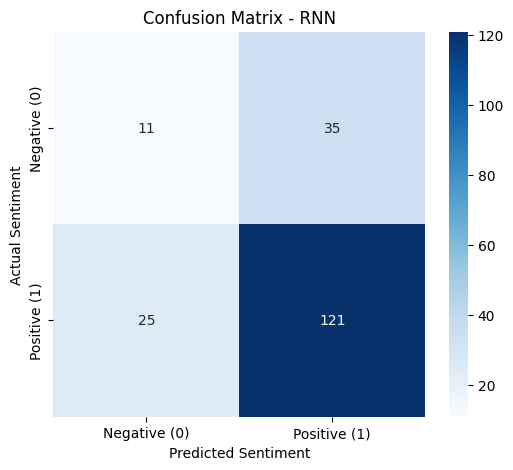


--- Testing Custom Input (RNN) ---
Review: 'Sistem pesannya ribet banget, padahal banyak meja kosong tapi disuruh nunggu.' -> Predicted Sentiment: Positive (1)
Review: 'Rasa mienya lumayan enak dan harganya murah, cocok buat tanggal tua.' -> Predicted Sentiment: Positive (1)


In [6]:
class SentimentRNN(nn.Module):
    """Vanilla RNN baseline for sentiment classification."""
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, output_dim=2, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.rnn(embedded)      # hidden: (1, batch, hidden_dim)
        out = self.dropout(hidden.squeeze(0))
        return self.fc(out)

rnn_model = SentimentRNN(VOCAB_SIZE)
print("\nTraining RNN model...")
rnn_model = train_model(rnn_model, train_loader, epochs=10)
evaluate_model(rnn_model, test_loader, 'RNN')

print("\n--- Testing Custom Input (RNN) ---")
preds = predict_custom(rnn_model, new_reviews, vocab)
for review, pred in zip(new_reviews, preds):
    print(f"Review: '{review}' -> Predicted Sentiment: {target_names[pred]}")



Training LSTM model...
Epoch 1/10 - Loss: 0.6752
Epoch 2/10 - Loss: 0.5113
Epoch 3/10 - Loss: 0.4214
Epoch 4/10 - Loss: 0.3143
Epoch 5/10 - Loss: 0.2563
Epoch 6/10 - Loss: 0.2187
Epoch 7/10 - Loss: 0.2207
Epoch 8/10 - Loss: 0.2689
Epoch 9/10 - Loss: 0.1843
Epoch 10/10 - Loss: 0.1571

--- Binary Classification Report (LSTM) ---
              precision    recall  f1-score   support

Negative (0)       0.89      0.70      0.78        46
Positive (1)       0.91      0.97      0.94       146

    accuracy                           0.91       192
   macro avg       0.90      0.83      0.86       192
weighted avg       0.91      0.91      0.90       192



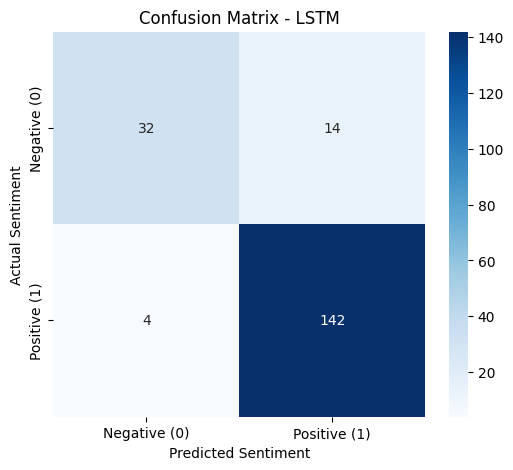


--- Testing Custom Input (LSTM) ---
Review: 'Sistem pesannya ribet banget, padahal banyak meja kosong tapi disuruh nunggu.' -> Predicted Sentiment: Negative (0)
Review: 'Rasa mienya lumayan enak dan harganya murah, cocok buat tanggal tua.' -> Predicted Sentiment: Positive (1)


In [7]:
class SentimentLSTM(nn.Module):
    """LSTM to capture longer-range dependencies and mitigate the vanishing-gradient issue of vanilla RNNs."""
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, output_dim=2, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, cell) = self.lstm(embedded)   # hidden: (1, batch, hidden_dim)
        out = self.dropout(hidden.squeeze(0))
        return self.fc(out)

lstm_model = SentimentLSTM(VOCAB_SIZE)
print("\nTraining LSTM model...")
lstm_model = train_model(lstm_model, train_loader, epochs=10)
evaluate_model(lstm_model, test_loader, 'LSTM')

print("\n--- Testing Custom Input (LSTM) ---")
preds = predict_custom(lstm_model, new_reviews, vocab)
for review, pred in zip(new_reviews, preds):
    print(f"Review: '{review}' -> Predicted Sentiment: {target_names[pred]}")



Training GRU model...
Epoch 1/10 - Loss: 0.6349
Epoch 2/10 - Loss: 0.4833
Epoch 3/10 - Loss: 0.3510
Epoch 4/10 - Loss: 0.3065
Epoch 5/10 - Loss: 0.2423
Epoch 6/10 - Loss: 0.2656
Epoch 7/10 - Loss: 0.2400
Epoch 8/10 - Loss: 0.2855
Epoch 9/10 - Loss: 0.2074
Epoch 10/10 - Loss: 0.1573

--- Binary Classification Report (GRU) ---
              precision    recall  f1-score   support

Negative (0)       0.73      0.80      0.76        46
Positive (1)       0.94      0.90      0.92       146

    accuracy                           0.88       192
   macro avg       0.83      0.85      0.84       192
weighted avg       0.89      0.88      0.88       192



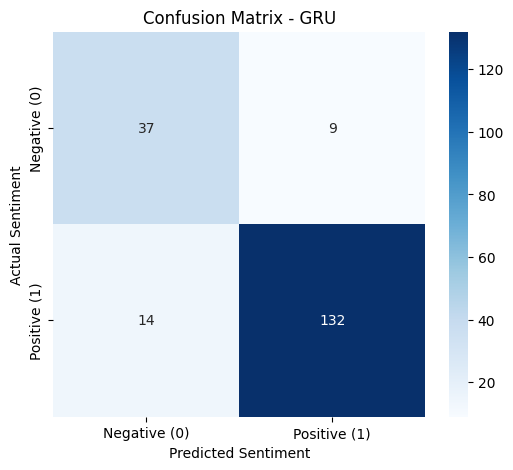


--- Testing Custom Input (GRU) ---
Review: 'Sistem pesannya ribet banget, padahal banyak meja kosong tapi disuruh nunggu.' -> Predicted Sentiment: Negative (0)
Review: 'Rasa mienya lumayan enak dan harganya murah, cocok buat tanggal tua.' -> Predicted Sentiment: Positive (1)


In [8]:
class SentimentGRU(nn.Module):
    """GRU as a lighter-weight alternative to LSTM (fewer gates, fewer parameters)."""
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, output_dim=2, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.gru(embedded)     # hidden: (1, batch, hidden_dim)
        out = self.dropout(hidden.squeeze(0))
        return self.fc(out)

gru_model = SentimentGRU(VOCAB_SIZE)
print("\nTraining GRU model...")
gru_model = train_model(gru_model, train_loader, epochs=10)
evaluate_model(gru_model, test_loader, 'GRU')

print("\n--- Testing Custom Input (GRU) ---")
preds = predict_custom(gru_model, new_reviews, vocab)
for review, pred in zip(new_reviews, preds):
    print(f"Review: '{review}' -> Predicted Sentiment: {target_names[pred]}")


In [9]:
# ---------------------------------------------------------------
# GPT (GPT-2) fine-tuned for binary sentiment classification
# Same evaluation protocol as IndoBERT above, for a fair comparison
# ---------------------------------------------------------------
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments

GPT_MODEL_NAME = "cahya/gpt2-small-indonesian-522M"  # Indonesian GPT-2 checkpoint

# Load & preprocess (same split logic as IndoBERT)
df_gpt = pd.read_csv("reviews.csv").drop(columns=["reviewer_name"])
df_gpt = df_gpt[df_gpt["rating"] != 3.0].copy()
df_gpt["sentiment"] = (df_gpt["rating"] > 2.0).astype(int)  # 0 = negative, 1 = positive

X_train_gpt, X_test_gpt, y_train_gpt, y_test_gpt = train_test_split(
    df_gpt["review_text"].astype(str).tolist(), df_gpt["sentiment"].tolist(),
    test_size=0.2, random_state=42, stratify=df_gpt["sentiment"]
)

# Tokenization
gpt_tokenizer = AutoTokenizer.from_pretrained(GPT_MODEL_NAME)
# GPT-2 has no pad token by default, reuse the end-of-sequence token instead
gpt_tokenizer.pad_token = gpt_tokenizer.eos_token

gpt_tokenize = lambda texts: gpt_tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
gpt_train_enc, gpt_test_enc = gpt_tokenize(X_train_gpt), gpt_tokenize(X_test_gpt)

# Reuses the ReviewDataset class defined in the IndoBERT cell above
gpt_train_dataset = ReviewDataset(gpt_train_enc, y_train_gpt)
gpt_test_dataset = ReviewDataset(gpt_test_enc, y_test_gpt)

# Model
gpt_model = AutoModelForSequenceClassification.from_pretrained(GPT_MODEL_NAME, num_labels=2)
gpt_model.config.pad_token_id = gpt_tokenizer.pad_token_id  # required for the classification head

# Class imbalance handling (same idea as scale_pos_weight in XGBoost)
gpt_class_weights = torch.tensor([1.0, y_train_gpt.count(0) / y_train_gpt.count(1)], dtype=torch.float)


class GPTWeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        logits = model(**inputs).logits
        loss = torch.nn.CrossEntropyLoss(weight=gpt_class_weights.to(logits.device))(logits, labels)
        return (loss, {"logits": logits}) if return_outputs else loss


# Training
gpt_training_args = TrainingArguments(
    output_dir="./gpt2-sentiment",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_steps=10,
)

gpt_trainer = GPTWeightedTrainer(model=gpt_model, args=gpt_training_args, train_dataset=gpt_train_dataset, eval_dataset=gpt_test_dataset)

print("\nTraining GPT model...")
gpt_trainer.train()

# Evaluation
y_pred_gpt = np.argmax(gpt_trainer.predict(gpt_test_dataset).predictions, axis=1)
target_names = ["Negative (0)", "Positive (1)"]

print("\n--- Binary Classification Report (GPT) ---")
print(classification_report(y_test_gpt, y_pred_gpt, target_names=target_names))
print(confusion_matrix(y_test_gpt, y_pred_gpt))

# Store metrics in the shared dictionary so it can be compared with other models at the end of the notebook
if 'model_results' not in globals():
    model_results = {}
model_results['GPT'] = {
    'accuracy': accuracy_score(y_test_gpt, y_pred_gpt),
    'f1_score': f1_score(y_test_gpt, y_pred_gpt, average='weighted')
}

# Inference on new reviews
new_reviews = [
    "Sistem pesannya ribet banget, padahal banyak meja kosong tapi disuruh nunggu.",
    "Rasa mienya lumayan enak dan harganya murah, cocok buat tanggal tua.",
]

gpt_model.eval()
gpt_inputs = {k: v.to(gpt_model.device) for k, v in gpt_tokenizer(new_reviews, padding=True, truncation=True, return_tensors="pt").items()}
with torch.no_grad():
    gpt_preds = torch.argmax(gpt_model(**gpt_inputs).logits, dim=1).tolist()

print("\n--- Testing Custom Input (GPT) ---")
for review, pred in zip(new_reviews, gpt_preds):
    print(f"Review: '{review}' -> Predicted Sentiment: {target_names[pred]}")

# Save model for reuse without retraining
gpt_trainer.save_model("./gpt2-sentiment-final")
gpt_tokenizer.save_pretrained("./gpt2-sentiment-final")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: cahya/gpt2-small-indonesian-522M
Key                                     | Status     | 
----------------------------------------+------------+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED | 
lm_head.weight                          | UNEXPECTED | 
score.weight                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training GPT model...


Epoch,Training Loss,Validation Loss
1,0.310842,0.152503
2,0.251563,0.192607
3,0.150548,0.218760
4,0.001106,0.463314
5,0.000103,0.241617
6,0.000174,0.264841
7,0.000005,0.322262
8,0.000008,0.316537
9,0.000020,0.311779
10,0.000042,0.304466


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- Binary Classification Report (GPT) ---
              precision    recall  f1-score   support

Negative (0)       0.86      0.91      0.88        46
Positive (1)       0.97      0.95      0.96       146

    accuracy                           0.94       192
   macro avg       0.91      0.93      0.92       192
weighted avg       0.94      0.94      0.94       192

[[ 42   4]
 [  7 139]]

--- Testing Custom Input (GPT) ---
Review: 'Sistem pesannya ribet banget, padahal banyak meja kosong tapi disuruh nunggu.' -> Predicted Sentiment: Negative (0)
Review: 'Rasa mienya lumayan enak dan harganya murah, cocok buat tanggal tua.' -> Predicted Sentiment: Positive (1)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./gpt2-sentiment-final\\tokenizer_config.json',
 './gpt2-sentiment-final\\tokenizer.json')

## Final Comparison Across All Models

Comparing **XGBoost (TF-IDF)**, **IndoBERT**, **RNN**, **LSTM**, and **GRU** based on accuracy and weighted F1-score on the same test set.

      model  accuracy  f1_score
0   XGBoost  0.895833  0.897280
1  IndoBERT  0.973958  0.974054
2       RNN  0.687500  0.673619
3      LSTM  0.906250  0.902086
4       GRU  0.880208  0.882252
5       GPT  0.942708  0.943316


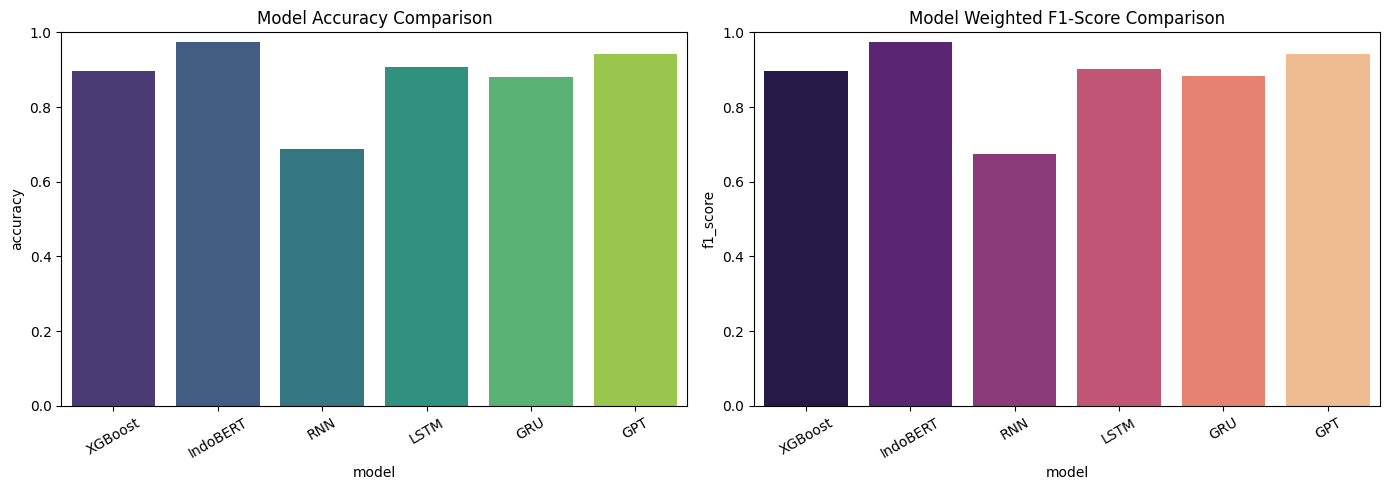


Best F1-score model: IndoBERT


In [12]:
# Compare all evaluated models (XGBoost, IndoBERT, RNN, LSTM, GRU)
if 'model_results' in globals() and model_results:
    results_df = pd.DataFrame(model_results).T.reset_index().rename(columns={'index': 'model'})
    print(results_df)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(data=results_df, x='model', y='accuracy', ax=axes[0], palette='viridis')
    axes[0].set_title('Model Accuracy Comparison')
    axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis='x', rotation=30)

    sns.barplot(data=results_df, x='model', y='f1_score', ax=axes[1], palette='magma')
    axes[1].set_title('Model Weighted F1-Score Comparison')
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis='x', rotation=30)
    
    plt.tight_layout()
    plt.show()

    best_model = results_df.loc[results_df['f1_score'].idxmax(), 'model']
    print(f"\nBest F1-score model: {best_model}")
else:
    print("No model results stored in 'model_results' yet. Run the model cells (XGBoost, IndoBERT, RNN, LSTM, GRU) first.")
